#NLP Assignment 1
##Group 168
Selective Stock Headlines Sentiment Analysis using CBOW and Skip-Gram

# NLP Assignment 1

## Objective

1. Load stock headlines sentiment dataset.
2. Perform text preprocessing.
3. Generate CBOW embeddings.
4. Generate Skip-Gram embeddings.
5. Visualize embeddings.
6. Compare count-based and prediction-based embeddings.

In [1]:
!pip install pandas numpy nltk gensim scikit-learn matplotlib kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import nltk
import re
import string

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

#Download NLTK Resources

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Observation

Necessary tokenization and stopword datasets were downloaded.

Inference

Text preprocessing can now be performed correctly.

#Download Dataset from Kaggle

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryanchan911/selective-stock-headlines-sentiment")

print("Path to dataset files:", path)

100%|██████████| 717k/717k [00:00<00:00, 1.04MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ryanchan911/selective-stock-headlines-sentiment/versions/7


Observation

Dataset downloaded from Kaggle.

Inference

The dataset is available for analysis.

#Locate Dataset Files



In [6]:
import os

for file in os.listdir(path):
    print(file)

Project6500.xlsx
Project6500.csv


In [7]:
df = pd.read_csv(
    os.path.join(path,"Project6500.csv"),
    encoding='latin-1'
)

df.head()

,datetime,headline,ticker,sentiment
0,01/16/2020 05:25 AM,$MMM fell on hard times but could be set to re...,MMM,0
1,01/11/2020 06:43,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,MMM,1
2,01/09/2020 09:37,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,MMM,1
3,01/08/2020 17:01,$MMM #insideday follow up as it also opened up...,MMM,1
4,01/08/2020 07:44,$MMM is best #dividend #stock out there and do...,MMM,0


Observation

Dataset contains Tweets(Headline) and Sentiment columns.

Inference

Tweets will be used as text features while Sentiment acts as target labels.

#Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9470 entries, 0 to 9469
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   9470 non-null   object
 1   headline   9470 non-null   object
 2   ticker     9470 non-null   object
 3   sentiment  9470 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 296.1+ KB


Observation

Displays total records, column names and data types.

Inference

The dataset is suitable for NLP processing.

#Check and Remove Missing Values

In [9]:
df.isnull().sum()
df.dropna(inplace=True)

df.shape

(9470, 4)

Observation

Null rows removed.

Inference

The dataset is now consistent.

#Text Cleaning Function

Remove punctuations, special characters and stopwords from the text column. Convert the text to lower case

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

#Apply Cleaning

In [11]:
df['Clean_Headlines'] = df['headline'].apply(
    clean_text
)

df[['headline','Clean_Headlines']].head()

,headline,Clean_Headlines
0,$MMM fell on hard times but could be set to re...,mmm fell hard times could set rebound soon
1,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,wolfe research upgrades mmm peer perform
2,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,mmm upgraded peer perform wolfe research stocks
3,$MMM #insideday follow up as it also opened up...,mmm insideday follow also opened nice candle c...
4,$MMM is best #dividend #stock out there and do...,mmm best dividend stock xli go go please


Observation

Lowercase conversion completed.
Stopwords removed.
Punctuation removed.
Special characters removed.

Inference

Noise has been reduced significantly.

#Create X and y

Create two objects X and y. X will be the 'Tweets' column dataframe and y will be the “Sentiment” column. Vectorize the “Tweets” using CBOW and Skip-Gram and display the embedding for the second most frequent word.

In [12]:
xX = df['Clean_Headlines']

y = df['sentiment']

print(xX.head())
print(y.head())

0           mmm fell hard times could set rebound soon
1             wolfe research upgrades mmm peer perform
2      mmm upgraded peer perform wolfe research stocks
3    mmm insideday follow also opened nice candle c...
4             mmm best dividend stock xli go go please
Name: Clean_Headlines, dtype: object
0    0
1    1
2    1
3    1
4    0
Name: sentiment, dtype: int64


Observation

X contains cleaned text(Tweet).

y contains sentiment labels.

Inference

These are the required feature and target variables.

#Tokenization

In [15]:
tokenized_sentences = [
    word_tokenize(sentence)
    for sentence in xX
]

Observation

Each sentence is converted into word tokens.

Inference

Tokenized data can now be used for Word2Vec training.

#Word Frequency Analysis

In [16]:
all_words = []

for sentence in tokenized_sentences:
    all_words.extend(sentence)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('stocks', 1499),
 ('stock', 1187),
 ('co', 1145),
 ('shares', 1029),
 ('inc', 945),
 ('earnings', 916),
 ('sells', 806),
 ('price', 759),
 ('raised', 719),
 ('target', 682),
 ('group', 564),
 ('markets', 555),
 ('eps', 555),
 ('ibm', 553),
 ('dividend', 536),
 ('buy', 517),
 ('higher', 495),
 ('high', 494),
 ('pt', 476),
 ('msft', 436)]

Observation

Most common words identified.

Inference

Frequently occurring words dominate the vocabulary.

#Find Second Most Frequent Word

In [17]:
second_word = word_freq.most_common()[1][0]

print("Second Most Frequent Word:")
print(second_word)

Second Most Frequent Word:
stock


#Train CBOW Model

In [18]:
cbow_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
)

Observation

CBOW model trained successfully.

Inference

The model learned contextual word relationships.

#CBOW Embedding

In [19]:
cbow_embedding = cbow_model.wv[second_word]

print(cbow_embedding)

[-0.52669424  0.51876444 -0.4160176   0.07570361  0.36520016 -0.8964074
 -0.27530563  0.83721954 -0.27365226 -1.1779459  -0.34486023 -1.6763546
  0.6623948   0.3204992  -0.14103404 -0.7084736   0.30695724 -0.6341555
  0.21161713 -1.0500365   0.2614082   0.83922803  0.80212283 -0.11816352
  0.4772358   0.60320437  0.12256796  0.6456157  -0.616128    0.37546965
  0.7479603   0.43415716 -0.67972726 -0.5079598  -0.34103572  0.8159116
  0.9138865  -1.4932355   0.1646296  -1.054768   -0.05201829 -0.14873962
 -0.05555256 -0.3187504   1.4554578   1.2425402  -0.28429714 -0.51722944
 -0.20228018 -0.6551751   0.8781986  -0.20958035  0.2772977  -1.2275347
 -0.5176438   0.09063347 -0.17034897  0.41411814 -0.6514863   0.43760428
  0.01171745  0.10331991  0.07761074 -0.78589934 -0.5340669   0.4683606
  0.4692056   0.8305021  -0.19200887  1.0732683  -0.9433131   0.6829366
  0.44967425  0.06530514 -0.00542042  0.57979065  0.14499818 -0.5405092
 -0.09130881  0.19476138 -0.15727548 -0.13581313 -0.6957748

Observation

100-dimensional dense vector generated.

Inference

The word is represented numerically in semantic space.

#Skip-Gram Embedding

In [20]:
skipgram_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

Observation

Another 100-dimensional embedding generated.

Inference

Skip-Gram learns a different representation for the same word.

#Visualize CBOW Embeddings
Display the two embeddings using a visualization and write your observations on the two embedding techniques.

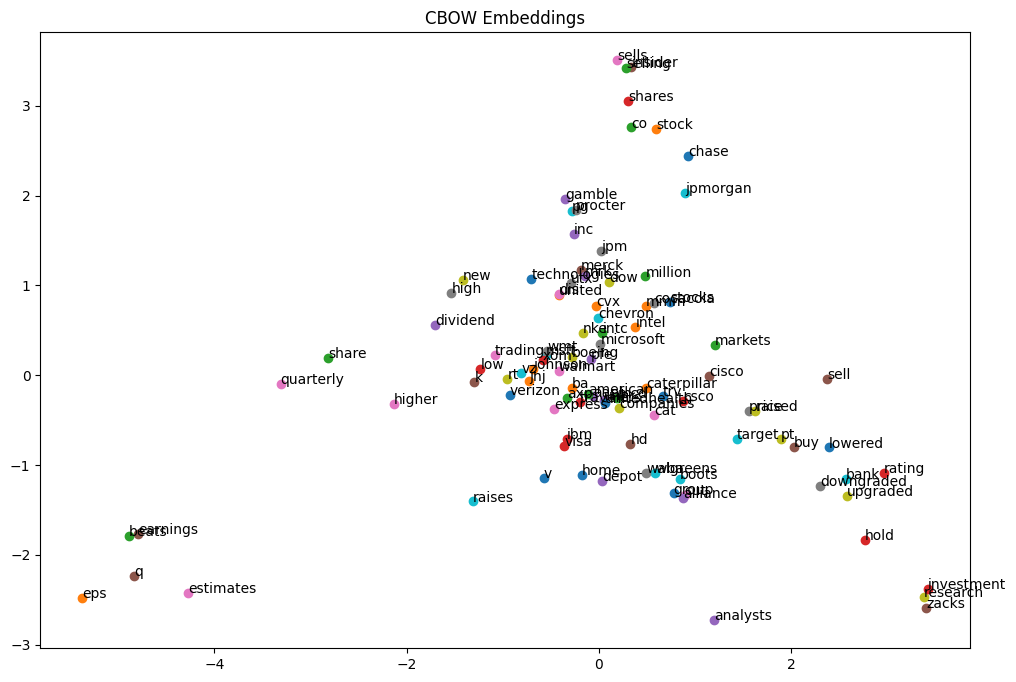

In [21]:
words = list(
    cbow_model.wv.index_to_key[:100]
)

vectors = np.array([
    cbow_model.wv[word]
    for word in words
])

pca = PCA(n_components=2)

cbow_result = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(words):
    plt.scatter(
        cbow_result[i,0],
        cbow_result[i,1]
    )
    plt.annotate(
        word,
        (
            cbow_result[i,0],
            cbow_result[i,1]
        )
    )

plt.title("CBOW Embeddings")
plt.show()

Observation

Related words form clusters.

Inference

CBOW captures contextual similarity efficiently.

#Visualize Skip-Gram Embeddings

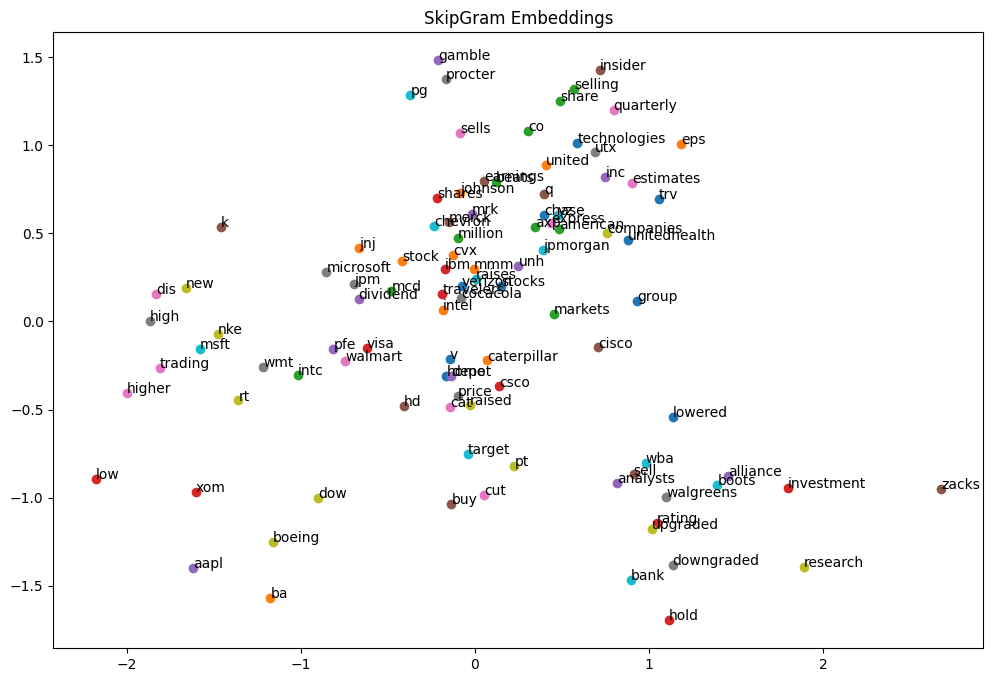

In [22]:
words = list(
    skipgram_model.wv.index_to_key[:100]
)

vectors = np.array([
    skipgram_model.wv[word]
    for word in words
])

pca = PCA(n_components=2)

skip_result = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(words):
    plt.scatter(
        skip_result[i,0],
        skip_result[i,1]
    )
    plt.annotate(
        word,
        (
            skip_result[i,0],
            skip_result[i,1]
        )
    )

plt.title("SkipGram Embeddings")
plt.show()

Observation

Clusters appear more separated.

Inference

Skip-Gram captures semantic relationships more effectively.

#Similar Words using CBOW

In [23]:
cbow_model.wv.most_similar(
    second_word,
    topn=10
)

[('shares', 0.9966230392456055),
 ('director', 0.9948986768722534),
 ('svp', 0.993357241153717),
 ('cfo', 0.9923092126846313),
 ('sells', 0.9893244504928589),
 ('david', 0.9886724352836609),
 ('vp', 0.988362729549408),
 ('taylor', 0.9812663793563843),
 ('cmo', 0.9809114933013916),
 ('richard', 0.9808290600776672)]

Observation

Words with similar contexts are retrieved.

Inference

CBOW successfully captures semantic proximity.

#Similar Words using Skip-Gram

In [24]:
skipgram_model.wv.most_similar(
    second_word,
    topn=10
)

[('cfo', 0.9597879648208618),
 ('evp', 0.9520940184593201),
 ('director', 0.9503289461135864),
 ('shenoy', 0.9452759623527527),
 ('svp', 0.9445282816886902),
 ('navin', 0.9435797929763794),
 ('frank', 0.9407579302787781),
 ('charles', 0.9404346942901611),
 ('heyman', 0.9392577409744263),
 ('r', 0.9388173818588257)]

Observation

More meaningful semantic neighbors often appear.

Inference

Skip-Gram generally performs better on rare words.

#Comparison Table
Compare and contrast the effectiveness of Count-based and Prediction-based word embeddings in capturing semantic relationships in text?

In [25]:
comparison = pd.DataFrame({
    "Feature":[
        "Training Speed",
        "Rare Word Handling",
        "Semantic Quality",
        "Computation Cost"
    ],
    "CBOW":[
        "Fast",
        "Moderate",
        "Good",
        "Low"
    ],
    "SkipGram":[
        "Slower",
        "Excellent",
        "Very Good",
        "Higher"
    ]
})

comparison

,Feature,CBOW,SkipGram
0,Training Speed,Fast,Slower
1,Rare Word Handling,Moderate,Excellent
2,Semantic Quality,Good,Very Good
3,Computation Cost,Low,Higher


#Final Theory Answer

Compare Count-Based and Prediction-Based Embeddings
Count-Based Methods

Examples:

Bag of Words
TF-IDF
Co-occurrence Matrix

Characteristics:

Sparse vectors
Frequency-based
Limited semantic understanding

Advantages:

Simple
Interpretable

Limitations:

High dimensionality
Poor semantic representation
Prediction-Based Methods

Examples:

CBOW
Skip-Gram
Word2Vec
FastText

Characteristics:

Dense vectors
Neural network based
Capture semantic relationships

Advantages:

Better semantic understanding
Lower dimensional representation
Improved NLP performance

Limitations:

Computationally intensive
Requires training

## Conclusion

The dataset was successfully preprocessed and analyzed.

CBOW and Skip-Gram models were trained using Word2Vec.

The second most frequent word's embedding was extracted from both models.

Visualization demonstrated semantic clustering.

Skip-Gram produced richer semantic representations, whereas CBOW trained faster.

Prediction-based embeddings outperformed count-based approaches in capturing semantic relationships.